# Saudi Synthetic AOI Demand Forecasting with XGBoost

This notebook trains an XGBoost forecasting model on synthetic Saudi hourly AOI demand data generated by `saudi_generator_v3.py`.

## Goals
- Mimic the structure of the Chinese LaDe training notebook
- Use strong lag-based forecasting features
- Train XGBoost models for hourly demand prediction
- Evaluate using:
  - rounded exact-match accuracy
  - MAE
  - RMSE
  - RMSLE
  - Poisson deviance

## Expected input file
- `saudi_synth_hourly_2024.csv`

In [1]:
# Optional: install packages if needed
# !pip install xgboost pandas numpy scikit-learn matplotlib

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATA_PATH = "saudi_synth_hourly_2024.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Make sure you ran saudi_generator_v3.py first."
    )

df = pd.read_csv(DATA_PATH, parse_dates=["bucket_hour"])
print(df.shape)
df.head()

(843264, 19)


,bucket_hour,city,region_id,aoi_id,aoi_name,aoi_archetype,demand_count,hour,day_of_week,month,is_weekend,is_ramadan,is_eid,is_eid_pre,is_white_friday,is_national_day,is_founding_day,is_back_to_school,is_hajj
0,2024-01-01 00:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,0,0,1,0,0,0,0,0,0,0,0,0
1,2024-01-01 01:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,1,0,1,0,0,0,0,0,0,0,0,0
2,2024-01-01 02:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,2,0,1,0,0,0,0,0,0,0,0,0
3,2024-01-01 03:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,3,0,1,0,0,0,0,0,0,0,0,0
4,2024-01-01 04:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,4,0,1,0,0,0,0,0,0,0,0,0


## 1. Quick sanity check

In [3]:
print("Date range:", df["bucket_hour"].min(), "->", df["bucket_hour"].max())
print("Rows:", len(df))
print("AOIs:", df["aoi_id"].nunique())
print("Regions:", df["region_id"].nunique())
print("City values:", df["city"].unique())
print("Demand mean:", df["demand_count"].mean())
print("Demand median:", df["demand_count"].median())
print("Demand max:", df["demand_count"].max())
print("Zero share:", (df["demand_count"] == 0).mean())
print()

display(df.dtypes)
display(df.head())

Date range: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Rows: 843264
AOIs: 96
Regions: 10
City values: ['Riyadh']
Demand mean: 0.7059343218731026
Demand median: 0.0
Demand max: 93
Zero share: 0.8774950667880995



,0
bucket_hour,datetime64[ns]
city,object
region_id,int64
aoi_id,int64
aoi_name,object
aoi_archetype,object
demand_count,int64
hour,int64
day_of_week,int64
month,int64


,bucket_hour,city,region_id,aoi_id,aoi_name,aoi_archetype,demand_count,hour,day_of_week,month,is_weekend,is_ramadan,is_eid,is_eid_pre,is_white_friday,is_national_day,is_founding_day,is_back_to_school,is_hajj
0,2024-01-01 00:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,0,0,1,0,0,0,0,0,0,0,0,0
1,2024-01-01 01:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,1,0,1,0,0,0,0,0,0,0,0,0
2,2024-01-01 02:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,2,0,1,0,0,0,0,0,0,0,0,0
3,2024-01-01 03:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,3,0,1,0,0,0,0,0,0,0,0,0
4,2024-01-01 04:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,4,0,1,0,0,0,0,0,0,0,0,0


In [4]:
df = df.sort_values(["aoi_id", "bucket_hour"]).reset_index(drop=True)

# Make sure each AOI is time-ordered
check = df.groupby("aoi_id")["bucket_hour"].diff().dropna()
print("Min time diff:", check.min())
print("Max time diff:", check.max())

Min time diff: 0 days 01:00:00
Max time diff: 0 days 01:00:00


## 2. Add extra time features
These are similar to what helped in the Chinese notebook:
- cyclical hour encoding
- cyclical day-of-week encoding
- cyclical month encoding
- year progress features

In [5]:
df["day_of_year"] = df["bucket_hour"].dt.dayofyear
df["week_of_year"] = df["bucket_hour"].dt.isocalendar().week.astype(int)
df["quarter"] = df["bucket_hour"].dt.quarter.astype(int)

# Cyclical features
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 366)
df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 366)

display(df.head())

,bucket_hour,city,region_id,aoi_id,aoi_name,aoi_archetype,demand_count,hour,day_of_week,month,is_weekend,is_ramadan,is_eid,is_eid_pre,is_white_friday,is_national_day,is_founding_day,is_back_to_school,is_hajj,day_of_year,week_of_year,quarter,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,2024-01-01 00:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0.000000,1.000000,0.0,1.0,0.5,0.866025,0.017166,0.999853
1,2024-01-01 01:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,0.017166,0.999853
2,2024-01-01 02:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,2,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0.500000,0.866025,0.0,1.0,0.5,0.866025,0.017166,0.999853
3,2024-01-01 03:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,3,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0.707107,0.707107,0.0,1.0,0.5,0.866025,0.017166,0.999853
4,2024-01-01 04:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,4,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0.866025,0.500000,0.0,1.0,0.5,0.866025,0.017166,0.999853


## 3. Create lag and rolling features
These are the most important forecasting features.

We use:
- short lags: 1, 2, 3
- daily / weekly lags: 24, 25, 48, 72, 168
- rolling statistics using only past information

In [6]:
group = df.groupby("aoi_id", group_keys=False)

lag_cols = [1, 2, 3, 24, 25, 48, 72, 168]
for lag in lag_cols:
    df[f"lag_{lag}"] = group["demand_count"].shift(lag)

# Rolling features from past only
df["roll_24_mean"] = group["demand_count"].shift(1).rolling(24).mean().reset_index(level=0, drop=True)
df["roll_24_std"]  = group["demand_count"].shift(1).rolling(24).std().reset_index(level=0, drop=True)
df["roll_24_max"]  = group["demand_count"].shift(1).rolling(24).max().reset_index(level=0, drop=True)

df["roll_72_mean"] = group["demand_count"].shift(1).rolling(72).mean().reset_index(level=0, drop=True)
df["roll_72_std"]  = group["demand_count"].shift(1).rolling(72).std().reset_index(level=0, drop=True)

df["roll_168_mean"] = group["demand_count"].shift(1).rolling(168).mean().reset_index(level=0, drop=True)
df["roll_168_std"]  = group["demand_count"].shift(1).rolling(168).std().reset_index(level=0, drop=True)

display(df.head(30))

,bucket_hour,city,region_id,aoi_id,aoi_name,aoi_archetype,demand_count,hour,day_of_week,month,is_weekend,is_ramadan,is_eid,is_eid_pre,is_white_friday,is_national_day,is_founding_day,is_back_to_school,is_hajj,day_of_year,week_of_year,quarter,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,lag_1,lag_2,lag_3,lag_24,lag_25,lag_48,lag_72,lag_168,roll_24_mean,roll_24_std,roll_24_max,roll_72_mean,roll_72_std,roll_168_mean,roll_168_std
0,2024-01-01 00:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0.000000e+00,1.000000e+00,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,1,2.588190e-01,9.659258e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,2,0,1,0,0,0,0,0,0,0,0,0,1,1,1,5.000000e-01,8.660254e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,3,0,1,0,0,0,0,0,0,0,0,0,1,1,1,7.071068e-01,7.071068e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 04:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,4,0,1,0,0,0,0,0,0,0,0,0,1,1,1,8.660254e-01,5.000000e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-01-01 05:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,5,0,1,0,0,0,0,0,0,0,0,0,1,1,1,9.659258e-01,2.588190e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-01-01 06:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,1,6,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1.000000e+00,6.123234e-17,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-01-01 07:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,7,0,1,0,0,0,0,0,0,0,0,0,1,1,1,9.659258e-01,-2.588190e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-01-01 08:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,8,0,1,0,0,0,0,0,0,0,0,0,1,1,1,8.660254e-01,-5.000000e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-01-01 09:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,9,0,1,0,0,0,0,0,0,0,0,0,1,1,1,7.071068e-01,-7.071068e-01,0.000000,1.00000,0.5,0.866025,0.017166,0.999853,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Neighbor / region context features
This is similar to the regional context idea in the Chinese notebook.

We use:
- region mean lag-24
- region mean lag-168
- region mean rolling 24

In [7]:
df["region_lag24_mean"] = (
    df.groupby(["region_id", "bucket_hour"])["lag_24"]
      .transform("mean")
)

df["region_lag168_mean"] = (
    df.groupby(["region_id", "bucket_hour"])["lag_168"]
      .transform("mean")
)

df["region_roll24_mean"] = (
    df.groupby(["region_id", "bucket_hour"])["roll_24_mean"]
      .transform("mean")
)

display(df[[
    "bucket_hour", "region_id", "aoi_id", "lag_24",
    "region_lag24_mean", "lag_168", "region_lag168_mean",
    "roll_24_mean", "region_roll24_mean"
]].head(20))

,bucket_hour,region_id,aoi_id,lag_24,region_lag24_mean,lag_168,region_lag168_mean,roll_24_mean,region_roll24_mean
0,2024-01-01 00:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 04:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-01-01 05:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-01-01 06:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-01-01 07:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-01-01 08:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-01-01 09:00:00,6,100001,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Drop early rows with missing lag history
Because we use up to lag 168 and rolling windows, the first part of each AOI series must be dropped.

In [8]:
before_rows = len(df)

required_cols = [
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_25", "lag_48", "lag_72", "lag_168",
    "roll_24_mean", "roll_24_std", "roll_24_max",
    "roll_72_mean", "roll_72_std",
    "roll_168_mean", "roll_168_std",
    "region_lag24_mean", "region_lag168_mean", "region_roll24_mean"
]

df_model = df.dropna(subset=required_cols).copy().reset_index(drop=True)

print("Rows before:", before_rows)
print("Rows after :", len(df_model))
print("Dropped    :", before_rows - len(df_model))
df_model.head()

Rows before: 843264
Rows after : 827136
Dropped    : 16128


,bucket_hour,city,region_id,aoi_id,aoi_name,aoi_archetype,demand_count,hour,day_of_week,month,is_weekend,is_ramadan,is_eid,is_eid_pre,is_white_friday,is_national_day,is_founding_day,is_back_to_school,is_hajj,day_of_year,week_of_year,quarter,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,lag_1,lag_2,lag_3,lag_24,lag_25,lag_48,lag_72,lag_168,roll_24_mean,roll_24_std,roll_24_max,roll_72_mean,roll_72_std,roll_168_mean,roll_168_std,region_lag24_mean,region_lag168_mean,region_roll24_mean
0,2024-01-08 00:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,0,0,1,0,0,0,0,0,0,0,0,0,8,2,1,0.000000,1.000000,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.0,0.0,0.875000
1,2024-01-08 01:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,1,0,1,0,0,0,0,0,0,0,0,0,8,2,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.1,0.0,0.875000
2,2024-01-08 02:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,2,0,1,0,0,0,0,0,0,0,0,0,8,2,1,0.500000,0.866025,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.1,0.1,0.883333
3,2024-01-08 03:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,3,0,1,0,0,0,0,0,0,0,0,0,8,2,1,0.707107,0.707107,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.4,0.0,0.879167
4,2024-01-08 04:00:00,Riyadh,6,100001,Central Core_CommercialMidday_01,commercial_midday,0,4,0,1,0,0,0,0,0,0,0,0,0,8,2,1,0.866025,0.500000,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.0,0.0,0.883333


## 6. Time-based split
We split chronologically, not randomly.

Suggested split:
- Train: through end of August
- Validation: September + October
- Test: November + December

In [9]:
TRAIN_END = pd.Timestamp("2024-08-31 23:00:00")
VAL_END   = pd.Timestamp("2024-10-31 23:00:00")

df_model["split"] = np.where(
    df_model["bucket_hour"] <= TRAIN_END, "train",
    np.where(df_model["bucket_hour"] <= VAL_END, "val", "test")
)

display(df_model["split"].value_counts())

train_df = df_model[df_model["split"] == "train"].copy()
val_df   = df_model[df_model["split"] == "val"].copy()
test_df  = df_model[df_model["split"] == "test"].copy()

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["bucket_hour"].min(), "->", train_df["bucket_hour"].max())
print("Val:  ", val_df["bucket_hour"].min(), "->", val_df["bucket_hour"].max())
print("Test: ", test_df["bucket_hour"].min(), "->", test_df["bucket_hour"].max())

,count
split,
train,546048
val,140544
test,140544


Train shape: (546048, 49)
Val shape:   (140544, 49)
Test shape:  (140544, 49)

Time ranges:
Train: 2024-01-08 00:00:00 -> 2024-08-31 23:00:00
Val:   2024-09-01 00:00:00 -> 2024-10-31 23:00:00
Test:  2024-11-01 00:00:00 -> 2024-12-31 23:00:00


## 7. Target encoding for AOI ID
We fit the AOI mean demand encoding only on the training set to avoid leakage.

In [10]:
global_train_mean = train_df["demand_count"].mean()

aoi_target_mean = train_df.groupby("aoi_id")["demand_count"].mean()

for part in [train_df, val_df, test_df]:
    part["aoi_id_encoded"] = part["aoi_id"].map(aoi_target_mean).fillna(global_train_mean)

display(train_df[["aoi_id", "aoi_id_encoded"]].drop_duplicates().head(10))

,aoi_id,aoi_id_encoded
0,100001,0.412975
8616,100002,0.152954
17232,100003,0.354958
25848,100004,0.466948
34464,100005,2.036920
43080,100006,1.212904
51696,100007,1.524262
60312,100008,0.803094
68928,100009,1.255626
77544,100010,0.467124


## 8. Prepare modeling features
We keep:
- numeric IDs: region_id
- event flags
- time / cyclical features
- lag / rolling features
- target encoding
- one-hot encoding for archetype

We do **not** one-hot `aoi_id` because that would be too large and less elegant.

In [11]:
cat_cols = ["aoi_archetype"]
base_numeric_cols = [
    "region_id",
    "hour", "day_of_week", "month", "quarter", "week_of_year", "day_of_year",
    "is_weekend",
    "is_ramadan", "is_eid", "is_eid_pre", "is_white_friday",
    "is_national_day", "is_founding_day", "is_back_to_school", "is_hajj",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "day_of_year_sin", "day_of_year_cos",
    "aoi_id_encoded",
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_25", "lag_48", "lag_72", "lag_168",
    "roll_24_mean", "roll_24_std", "roll_24_max",
    "roll_72_mean", "roll_72_std",
    "roll_168_mean", "roll_168_std",
    "region_lag24_mean", "region_lag168_mean", "region_roll24_mean",
]

target_col = "demand_count"

def make_X_y(df_part):
    X = df_part[base_numeric_cols + cat_cols].copy()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
    y = df_part[target_col].astype(float).copy()
    return X, y

X_train, y_train = make_X_y(train_df)
X_val, y_val     = make_X_y(val_df)
X_test, y_test   = make_X_y(test_df)

# Align columns in case one split misses a category
X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Feature count:", X_train.shape[1])
print("Train X:", X_train.shape)
print("Val X:  ", X_val.shape)
print("Test X: ", X_test.shape)

display(X_train.head())

Feature count: 50
Train X: (546048, 50)
Val X:   (140544, 50)
Test X:  (140544, 50)


,region_id,hour,day_of_week,month,quarter,week_of_year,day_of_year,is_weekend,is_ramadan,is_eid,is_eid_pre,is_white_friday,is_national_day,is_founding_day,is_back_to_school,is_hajj,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,aoi_id_encoded,lag_1,lag_2,lag_3,lag_24,lag_25,lag_48,lag_72,lag_168,roll_24_mean,roll_24_std,roll_24_max,roll_72_mean,roll_72_std,roll_168_mean,roll_168_std,region_lag24_mean,region_lag168_mean,region_roll24_mean,aoi_archetype_commercial_midday,aoi_archetype_low_density,aoi_archetype_mall_leisure,aoi_archetype_mixed,aoi_archetype_nightlife,aoi_archetype_office_cluster,aoi_archetype_residential_evening
0,6,0,0,1,1,2,8,0,0,0,0,0,0,0,0,0,0.000000,1.000000,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.412975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.0,0.0,0.875000,True,False,False,False,False,False,False
1,6,1,0,1,1,2,8,0,0,0,0,0,0,0,0,0,0.258819,0.965926,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.412975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.1,0.0,0.875000,True,False,False,False,False,False,False
2,6,2,0,1,1,2,8,0,0,0,0,0,0,0,0,0,0.500000,0.866025,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.412975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.1,0.1,0.883333,True,False,False,False,False,False,False
3,6,3,0,1,1,2,8,0,0,0,0,0,0,0,0,0,0.707107,0.707107,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.412975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.4,0.0,0.879167,True,False,False,False,False,False,False
4,6,4,0,1,1,2,8,0,0,0,0,0,0,0,0,0,0.866025,0.500000,0.0,1.0,0.5,0.866025,0.136906,0.990584,0.412975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.791667,4.413213,21.0,1.569444,3.610729,1.238095,2.856316,0.0,0.0,0.883333,True,False,False,False,False,False,False


## 9. Sample weights
We give slightly higher importance to busier AOIs, similar to emphasizing meaningful demand zones.

In [12]:
aoi_train_avg = train_df.groupby("aoi_id")["demand_count"].mean()
train_weights = train_df["aoi_id"].map(aoi_train_avg).fillna(aoi_train_avg.mean())
train_weights = np.sqrt(1.0 + train_weights.values)

val_weights = val_df["aoi_id"].map(aoi_train_avg).fillna(aoi_train_avg.mean())
val_weights = np.sqrt(1.0 + val_weights.values)

print("Train weight stats:", train_weights.min(), train_weights.mean(), train_weights.max())

Train weight stats: 1.0422677590596603 1.298687479190708 2.1802963062671923


## 10. Evaluation helpers
The Chinese notebook used rounded exact-match accuracy.

So we compute:
- rounded exact accuracy
- MAE
- RMSE
- RMSLE
- Poisson deviance

In [13]:
def rounded_exact_accuracy(y_true, y_pred):
    y_true_i = np.round(np.asarray(y_true)).astype(int)
    y_pred_i = np.round(np.clip(np.asarray(y_pred), 0, None)).astype(int)
    return (y_true_i == y_pred_i).mean()

def rmsle(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def evaluate_predictions(name, y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)

    metrics = {
        "model": name,
        "accuracy": rounded_exact_accuracy(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "rmsle": rmsle(y_true, y_pred),
        "poisson_deviance": mean_poisson_deviance(y_true, np.clip(y_pred, 1e-9, None)),
    }
    return metrics

## 11. Baselines
We compare against simple baselines:
- lag_24
- lag_168
- roll_24_mean

In [14]:
baseline_results = []

for name, pred_col in [
    ("Baseline lag_24", "lag_24"),
    ("Baseline lag_168", "lag_168"),
    ("Baseline roll_24_mean", "roll_24_mean"),
]:
    m_val = evaluate_predictions(name + " (val)", val_df["demand_count"], val_df[pred_col])
    m_test = evaluate_predictions(name + " (test)", test_df["demand_count"], test_df[pred_col])

    baseline_results.append(m_val)
    baseline_results.append(m_test)

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df.sort_values(["model"]).reset_index(drop=True))

,model,accuracy,mae,rmse,rmsle,poisson_deviance
0,Baseline lag_168 (test),0.854309,0.450165,1.719310,0.345562,3.802618
1,Baseline lag_168 (val),0.863438,0.422053,1.689649,0.332902,3.507287
2,Baseline lag_24 (test),0.893692,0.213485,0.861957,0.180739,0.831830
3,Baseline lag_24 (val),0.900529,0.200037,0.848219,0.174890,0.792340
4,Baseline roll_24_mean (test),0.504746,1.162018,3.063638,0.664639,3.185641
5,Baseline roll_24_mean (val),0.537099,1.112246,3.170335,0.650662,3.118367


## 12. Train XGBoost models
We train two models:
- Poisson objective
- Squared log error objective

These are the closest to the Chinese setup.

In [15]:
poisson_model = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.2,
    tree_method="hist",
    device="cuda",
    eval_metric="mae",
    random_state=RANDOM_STATE,
)

sqlog_model = xgb.XGBRegressor(
    objective="reg:squaredlogerror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.2,
    tree_method="hist",
    device="cuda",
    eval_metric="mae",
    random_state=RANDOM_STATE,
)

In [16]:
poisson_model.fit(
    X_train, y_train,
    sample_weight=train_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

sqlog_model.fit(
    X_train, y_train,
    sample_weight=train_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Training finished.")

Training finished.


## 13. Validation results

In [17]:
val_pred_poisson = np.clip(poisson_model.predict(X_val), 0, None)
val_pred_sqlog   = np.clip(sqlog_model.predict(X_val), 0, None)

val_results = pd.DataFrame([
    evaluate_predictions("XGBoost Poisson (val)", y_val, val_pred_poisson),
    evaluate_predictions("XGBoost SquaredLog (val)", y_val, val_pred_sqlog),
])

display(val_results.sort_values("accuracy", ascending=False).reset_index(drop=True))

,model,accuracy,mae,rmse,rmsle,poisson_deviance
0,XGBoost SquaredLog (val),0.901084,0.229600,1.073730,0.169953,0.268023
1,XGBoost Poisson (val),0.899910,0.221611,0.871823,0.172092,0.246238


## 14. Test results

In [18]:
test_pred_poisson = np.clip(poisson_model.predict(X_test), 0, None)
test_pred_sqlog   = np.clip(sqlog_model.predict(X_test), 0, None)

test_results = pd.DataFrame([
    evaluate_predictions("XGBoost Poisson (test)", y_test, test_pred_poisson),
    evaluate_predictions("XGBoost SquaredLog (test)", y_test, test_pred_sqlog),
])

display(test_results.sort_values("accuracy", ascending=False).reset_index(drop=True))

,model,accuracy,mae,rmse,rmsle,poisson_deviance
0,XGBoost SquaredLog (test),0.894332,0.237832,1.005461,0.175704,0.281126
1,XGBoost Poisson (test),0.893642,0.236352,0.906615,0.177734,0.259467


## 15. Combined comparison table
This is the main summary table.

In [19]:
all_results = pd.concat([
    baseline_results_df,
    val_results,
    test_results
], ignore_index=True)

display(all_results.sort_values(["accuracy", "mae"], ascending=[False, True]).reset_index(drop=True))

,model,accuracy,mae,rmse,rmsle,poisson_deviance
0,XGBoost SquaredLog (val),0.901084,0.229600,1.073730,0.169953,0.268023
1,Baseline lag_24 (val),0.900529,0.200037,0.848219,0.174890,0.792340
2,XGBoost Poisson (val),0.899910,0.221611,0.871823,0.172092,0.246238
3,XGBoost SquaredLog (test),0.894332,0.237832,1.005461,0.175704,0.281126
4,Baseline lag_24 (test),0.893692,0.213485,0.861957,0.180739,0.831830
5,XGBoost Poisson (test),0.893642,0.236352,0.906615,0.177734,0.259467
6,Baseline lag_168 (val),0.863438,0.422053,1.689649,0.332902,3.507287
7,Baseline lag_168 (test),0.854309,0.450165,1.719310,0.345562,3.802618
8,Baseline roll_24_mean (val),0.537099,1.112246,3.170335,0.650662,3.118367
9,Baseline roll_24_mean (test),0.504746,1.162018,3.063638,0.664639,3.185641


## 16. Best model selection
We choose the best model based on test rounded exact-match accuracy.

In [20]:
candidate_models = {
    "XGBoost Poisson": (poisson_model, test_pred_poisson),
    "XGBoost SquaredLog": (sqlog_model, test_pred_sqlog),
}

best_model_name, (best_model, best_test_pred) = max(
    candidate_models.items(),
    key=lambda x: rounded_exact_accuracy(y_test, x[1][1])
)

best_test_acc = rounded_exact_accuracy(y_test, best_test_pred)

print("Best model:", best_model_name)
print("Best test rounded exact-match accuracy:", round(best_test_acc, 6))

Best model: XGBoost SquaredLog
Best test rounded exact-match accuracy: 0.894332


## 17. Feature importance

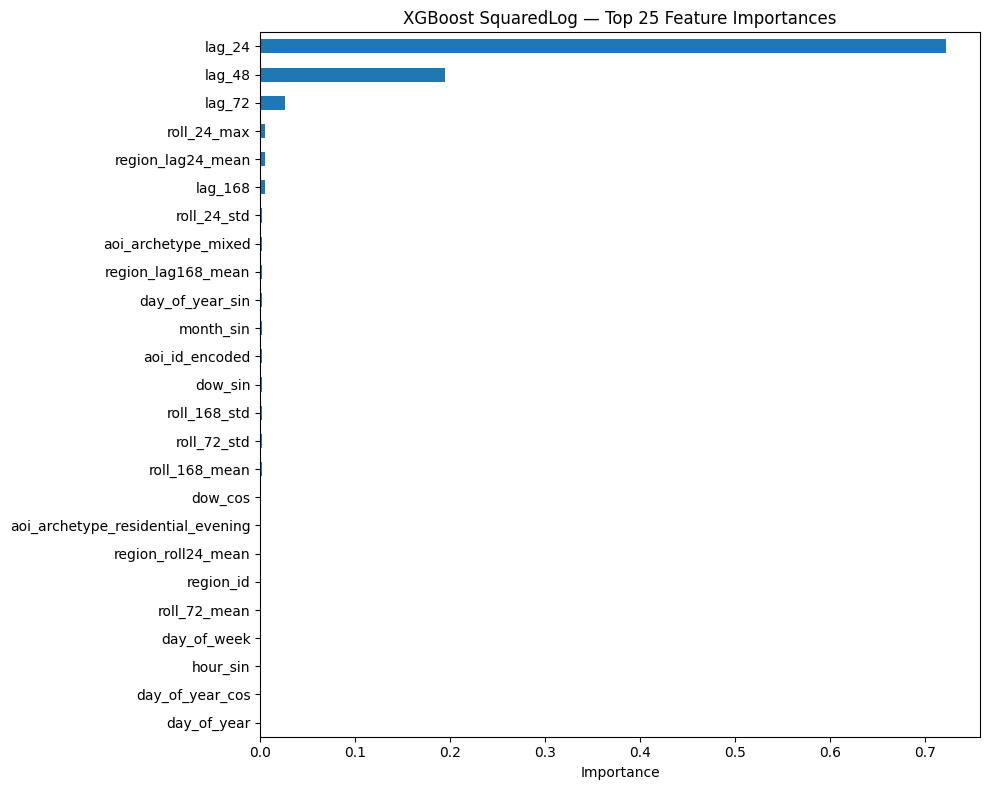

,importance
lag_24,0.722277
lag_48,0.194381
lag_72,0.026285
roll_24_max,0.005078
region_lag24_mean,0.004713
lag_168,0.004598
roll_24_std,0.001611
aoi_archetype_mixed,0.001430
region_lag168_mean,0.001399
day_of_year_sin,0.001362


In [21]:

importance = (
    pd.Series(best_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 8))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title(f"{best_model_name} — Top 25 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance.to_frame("importance"))

## 18. Compare predicted vs actual distribution

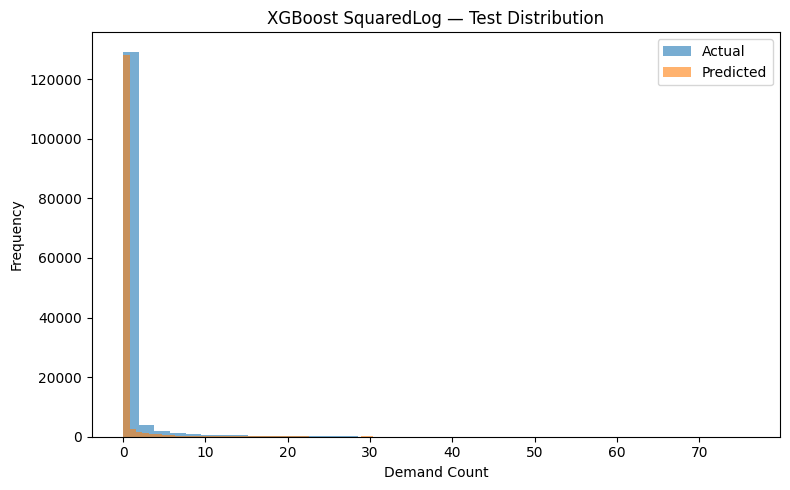

In [22]:
pred_compare = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": np.clip(best_test_pred, 0, None)
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pred_compare["y_true"], bins=40, alpha=0.6, label="Actual")
ax.hist(pred_compare["y_pred"], bins=40, alpha=0.6, label="Predicted")
ax.set_title(f"{best_model_name} — Test Distribution")
ax.set_xlabel("Demand Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 19. Sample prediction rows

In [23]:
sample_output = test_df[[
    "bucket_hour", "aoi_id", "region_id", "aoi_archetype",
    "demand_count", "lag_24", "lag_168", "roll_24_mean"
]].copy()

sample_output["prediction"] = np.round(np.clip(best_test_pred, 0, None)).astype(int)
sample_output["abs_error"] = np.abs(sample_output["demand_count"] - sample_output["prediction"])
sample_output["exact_match"] = (sample_output["demand_count"] == sample_output["prediction"]).astype(int)

display(sample_output.sample(20, random_state=RANDOM_STATE).sort_values(["aoi_id", "bucket_hour"]))

,bucket_hour,aoi_id,region_id,aoi_archetype,demand_count,lag_24,lag_168,roll_24_mean,prediction,abs_error,exact_match
24743,2024-11-15 23:00:00,100003,5,residential_evening,0,0.0,0.0,0.166667,0,0,1
154581,2024-12-10 21:00:00,100018,6,mall_leisure,9,16.0,15.0,3.166667,14,5,0
188639,2024-11-23 23:00:00,100022,10,office_cluster,0,0.0,0.0,1.791667,0,0,1
205419,2024-11-05 03:00:00,100024,5,mixed,1,0.0,0.0,0.500000,0,1,0
222681,2024-11-06 09:00:00,100026,10,mall_leisure,0,0.0,0.0,1.333333,0,0,1
240544,2024-12-02 16:00:00,100028,8,residential_evening,4,3.0,0.0,1.041667,2,2,0
310025,2024-12-25 17:00:00,100036,8,mixed,0,0.0,0.0,0.333333,0,0,1
326695,2024-12-02 07:00:00,100038,2,commercial_midday,0,0.0,0.0,1.250000,0,0,1
370164,2024-12-18 12:00:00,100043,4,mall_leisure,0,0.0,0.0,0.166667,0,0,1
387695,2024-12-30 23:00:00,100045,3,mall_leisure,0,0.0,0.0,0.125000,0,0,1


## 20. Save results

In [24]:
results_dir = "saudi_xgboost_results"
os.makedirs(results_dir, exist_ok=True)

all_results.to_csv(os.path.join(results_dir, "model_results.csv"), index=False)
importance.to_frame("importance").to_csv(os.path.join(results_dir, "feature_importance_top25.csv"))

summary = {
    "best_model_name": best_model_name,
    "best_test_accuracy": float(best_test_acc),
    "test_metrics": (
        evaluate_predictions(best_model_name + " (test)", y_test, best_test_pred)
    ),
    "feature_count": int(X_train.shape[1]),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
}

with open(os.path.join(results_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved files to:", results_dir)
print(json.dumps(summary, indent=2))

Saved files to: saudi_xgboost_results
{
  "best_model_name": "XGBoost SquaredLog",
  "best_test_accuracy": 0.8943320241347905,
  "test_metrics": {
    "model": "XGBoost SquaredLog (test)",
    "accuracy": 0.8943320241347905,
    "mae": 0.2378317100438141,
    "rmse": 1.0054611508828886,
    "rmsle": 0.17570369996974086,
    "poisson_deviance": 0.28112630888515217
  },
  "feature_count": 50,
  "train_rows": 546048,
  "val_rows": 140544,
  "test_rows": 140544
}
